# Phase 1 — Experiment Design and Covariate Balance

## Objective

This notebook evaluates whether the randomized treatment and control groups are comparable before estimating advertising effects.

The analysis covers:

- Experimental variable roles
- Treatment allocation
- Covariate means and variances
- Standardized mean differences
- Visual balance assessment

## Experimental Design

Each row represents one user in a randomized advertising incrementality experiment.

| Variable | Role |
|---|---|
| `f0–f11` | Pre-treatment user characteristics |
| `treatment` | Randomized assignment to the advertising strategy |
| `exposure` | Actual ad exposure after treatment assignment |
| `visit` | Website-visit outcome |
| `conversion` | Conversion outcome |

The primary causal comparison uses `treatment`, not `exposure`, because treatment was randomized while actual exposure depends on the auction process.

Only pre-treatment variables `f0–f11` are used for the balance assessment.

## Step 1 — Set Up the Analysis

In [4]:
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display


def find_project_root(start_path: Path) -> Path:
    """Find the project root containing the data and src folders."""
    candidates = [start_path, *start_path.parents]

    for candidate in candidates:
        if (candidate / "data").exists() and (candidate / "src").exists():
            return candidate

    raise FileNotFoundError("Could not locate the project root.")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
PARQUET_PATH = PROJECT_ROOT / "data" / "processed" / "criteo-uplift-v2.1.parquet"
FIGURE_DIRECTORY = PROJECT_ROOT / "reports" / "figures"
FIGURE_DIRECTORY.mkdir(parents=True, exist_ok=True)

if not PARQUET_PATH.exists():
    raise FileNotFoundError(f"Parquet file not found: {PARQUET_PATH}")

PARQUET_SQL_PATH = str(PARQUET_PATH).replace("'", "''")
feature_columns = [f"f{i}" for i in range(12)]
connection = duckdb.connect()

print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset: {PARQUET_PATH}")
print("Analysis environment ready.")

Project root: /Users/ever/Library/CloudStorage/OneDrive2-ColumbiaUniversityIrvingMedicalCenter/adlift项目
Dataset: /Users/ever/Library/CloudStorage/OneDrive2-ColumbiaUniversityIrvingMedicalCenter/adlift项目/data/processed/criteo-uplift-v2.1.parquet
Analysis environment ready.


### Conclusion

The processed Criteo dataset was located successfully, and all 12 pre-treatment features were selected for the balance assessment.

## Step 2 — Confirm Treatment Allocation

This step confirms the treatment-control sample sizes and verifies that both experimental groups are present.

In [5]:
allocation_summary = connection.execute(
    f"""
    SELECT
        treatment,
        COUNT(*) AS user_count,
        COUNT(*) * 1.0 / SUM(COUNT(*)) OVER () AS user_share
    FROM read_parquet('{PARQUET_SQL_PATH}')
    GROUP BY treatment
    ORDER BY treatment
    """
).df()

assert set(allocation_summary["treatment"]) == {0, 1}, (
    "Both treatment and control groups must be present."
)

allocation_summary["user_share"] *= 100

display(
    allocation_summary.style.format(
        {"user_count": "{:,.0f}", "user_share": "{:.2f}%"}
    )
)

,treatment,user_count,user_share
0,0,"2,096,937",15.00%
1,1,"11,882,655",85.00%


### Conclusion

The analysis population contains 2,096,937 control users (15%) and 11,882,655 treated users (85%). The allocation matches the documented experiment design and provides large samples for both groups.

## Step 3 — Calculate Standardized Mean Differences

Covariate balance is evaluated using the standardized mean difference:

$$
SMD_j = \frac{\bar{X}_{j,T}-\bar{X}_{j,C}}{\sqrt{(s_{j,T}^{2}+s_{j,C}^{2})/2}}
$$

Absolute SMD is interpreted using the following diagnostic thresholds:

- Below 0.05: negligible difference
- 0.05 to 0.10: small difference
- 0.10 or above: potentially meaningful imbalance

SMD is preferred over significance tests because the very large sample size can make trivial differences statistically significant.

In [6]:
aggregate_expressions = []

for feature in feature_columns:
    aggregate_expressions.extend(
        [
            f"AVG({feature}) FILTER (WHERE treatment = 0) AS {feature}_control_mean",
            f"STDDEV_POP({feature}) FILTER (WHERE treatment = 0) AS {feature}_control_sd",
            f"AVG({feature}) FILTER (WHERE treatment = 1) AS {feature}_treatment_mean",
            f"STDDEV_POP({feature}) FILTER (WHERE treatment = 1) AS {feature}_treatment_sd",
        ]
    )

balance_raw = connection.execute(
    f"""
    SELECT {', '.join(aggregate_expressions)}
    FROM read_parquet('{PARQUET_SQL_PATH}')
    """
).df().iloc[0]

balance_rows = []

for feature in feature_columns:
    control_mean = balance_raw[f"{feature}_control_mean"]
    control_sd = balance_raw[f"{feature}_control_sd"]
    treatment_mean = balance_raw[f"{feature}_treatment_mean"]
    treatment_sd = balance_raw[f"{feature}_treatment_sd"]
    pooled_sd = np.sqrt((control_sd**2 + treatment_sd**2) / 2)

    standardized_mean_difference = (
        (treatment_mean - control_mean) / pooled_sd
        if pooled_sd > 0
        else np.nan
    )
    variance_ratio = (
        treatment_sd**2 / control_sd**2
        if control_sd > 0
        else np.nan
    )

    balance_rows.append(
        {
            "feature": feature,
            "control_mean": control_mean,
            "treatment_mean": treatment_mean,
            "control_sd": control_sd,
            "treatment_sd": treatment_sd,
            "smd": standardized_mean_difference,
            "absolute_smd": abs(standardized_mean_difference),
            "variance_ratio": variance_ratio,
        }
    )

balance_table = (
    pd.DataFrame(balance_rows)
    .sort_values("absolute_smd", ascending=False)
    .reset_index(drop=True)
)

display(
    balance_table.style.format(
        {
            "control_mean": "{:.6f}",
            "treatment_mean": "{:.6f}",
            "control_sd": "{:.6f}",
            "treatment_sd": "{:.6f}",
            "smd": "{:.6f}",
            "absolute_smd": "{:.6f}",
            "variance_ratio": "{:.4f}",
        }
    )
)

,feature,control_mean,treatment_mean,control_sd,treatment_sd,smd,absolute_smd,variance_ratio
0,f3,4.232821,4.169412,1.242028,1.352432,-0.048836,0.048836,1.1857
1,f6,-3.999880,-4.182792,4.441984,4.600939,-0.040448,0.040448,1.0729
2,f5,4.039339,4.026602,0.395538,0.437045,-0.030557,0.030557,1.2209
3,f9,15.886253,16.052589,6.802161,7.056250,0.024001,0.024001,1.0761
4,f1,10.067935,10.070337,0.092990,0.106693,0.023994,0.023994,1.3164
5,f8,3.934652,3.933392,0.055445,0.056869,-0.022433,0.022433,1.0520
6,f7,5.080284,5.105555,1.163292,1.212461,0.021270,0.021270,1.0863
7,f10,5.331898,5.333660,0.164676,0.168847,0.010563,0.010563,1.0513
8,f4,10.336526,10.339245,0.338681,0.344117,0.007966,0.007966,1.0324
9,f0,19.651705,19.614755,5.388110,5.375564,-0.006866,0.006866,0.9953


### Practical Meaning

This determines whether the treatment and control groups were observably similar before treatment.
$$
\mathrm{SMD}
=
\frac{
\text{Treatment Mean} - \text{Control Mean}
}{
\text{Pooled Standard Deviation}
}
$$

### How to Interpret

An SMD near zero indicates stronger balance. The sign shows direction, while the absolute value measures imbalance. For `f3`, the SMD of -0.048836 means that the treatment mean is approximately 0.049 pooled standard deviations below the control mean; it does not represent a 4.9% difference.

### Conclusion

All 12 features have absolute SMD values below 0.05. The largest difference is observed for `f3` (0.048836), indicating strong mean balance between the treatment and control groups.

## Step 4 — Classify Covariate Balance

Each feature is classified according to its absolute standardized mean difference.

In [7]:
def classify_balance(absolute_smd: float) -> str:
    """Classify covariate balance using common SMD thresholds."""
    if absolute_smd < 0.05:
        return "Negligible"
    if absolute_smd < 0.10:
        return "Small"
    return "Potential imbalance"


balance_table["balance_status"] = balance_table["absolute_smd"].apply(
    classify_balance
)

balance_status_summary = (
    balance_table["balance_status"]
    .value_counts()
    .rename_axis("balance_status")
    .reset_index(name="feature_count")
)

display(balance_status_summary)

,balance_status,feature_count
0,Negligible,12


### Practical Meaning

The classification converts numerical SMD estimates into consistent diagnostic categories
Values below 0.05 are classified as negligible, values from 0.05 to 0.10 as small, and values of at least 0.10 as potential imbalance. These thresholds are diagnostics rather than hypothesis-test cutoffs.

### Conclusion

All 12 pre-treatment features are classified as having negligible mean imbalance. No feature requires corrective action based on the 0.05 or 0.10 SMD thresholds.

## Step 5 — Create the Covariate Balance Plot

The balance plot displays the absolute SMD for each feature. Values closer to zero indicate stronger treatment-control comparability.

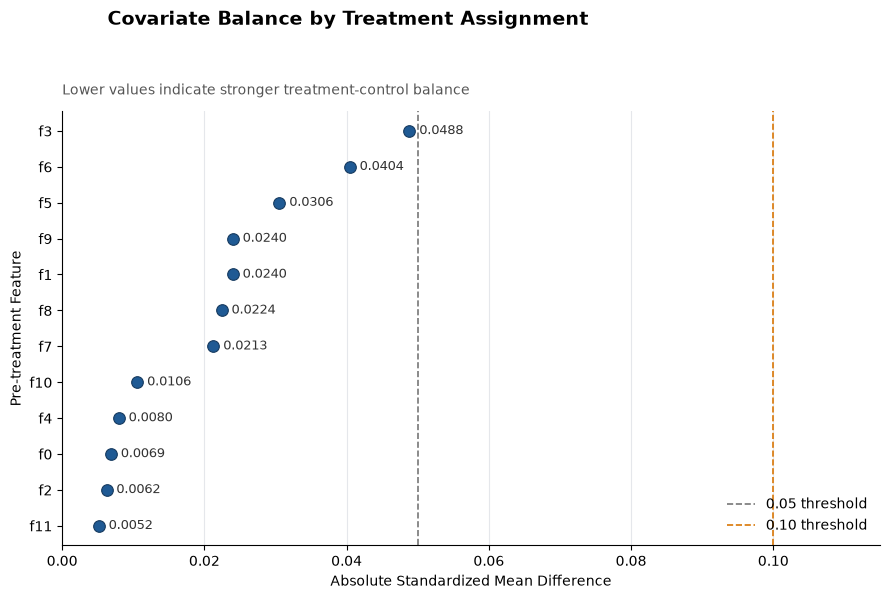

Figure saved to: /Users/ever/Library/CloudStorage/OneDrive2-ColumbiaUniversityIrvingMedicalCenter/adlift项目/reports/figures/covariate_balance_smd.png


In [8]:
plot_data = balance_table.sort_values("absolute_smd", ascending=True).copy()
maximum_smd = plot_data["absolute_smd"].max()
x_axis_limit = max(0.115, maximum_smd * 1.25)

figure, axis = plt.subplots(figsize=(9, 6))

axis.scatter(
    plot_data["absolute_smd"],
    plot_data["feature"],
    color="#1F5A94",
    edgecolor="#163A5F",
    linewidth=0.8,
    s=70,
    zorder=3,
)

axis.axvline(0.05, color="#777777", linestyle="--", linewidth=1.2, label="0.05 threshold")
axis.axvline(0.10, color="#D97706", linestyle="--", linewidth=1.2, label="0.10 threshold")

for _, row in plot_data.iterrows():
    axis.text(
        row["absolute_smd"] + x_axis_limit * 0.012,
        row["feature"],
        f'{row["absolute_smd"]:.4f}',
        va="center",
        fontsize=9,
        color="#333333",
    )

axis.set_xlim(0, x_axis_limit)
axis.set_xlabel("Absolute Standardized Mean Difference")
axis.set_ylabel("Pre-treatment Feature")
figure.suptitle(
    "Covariate Balance by Treatment Assignment",
    x=0.125,
    y=0.99,
    ha="left",
    fontsize=14,
    fontweight="bold",
)
axis.set_title(
    "Lower values indicate stronger treatment-control balance",
    loc="left",
    fontsize=10,
    color="#555555",
    pad=12,
)
axis.grid(axis="x", color="#E5E7EB", linewidth=0.8)
axis.legend(frameon=False, loc="lower right")
axis.spines["top"].set_visible(False)
axis.spines["right"].set_visible(False)

figure.tight_layout(rect=[0, 0, 1, 0.95])
BALANCE_FIGURE_PATH = FIGURE_DIRECTORY / "covariate_balance_smd.png"
figure.savefig(BALANCE_FIGURE_PATH, dpi=300, bbox_inches="tight")
plt.show()

print(f"Figure saved to: {BALANCE_FIGURE_PATH}")


### How to Interpret

Points closer to zero indicate stronger balance. `f3` is closest to the 0.05 threshold, followed by `f6`, but both remain below it. The `f1` variance ratio of 1.3164 indicates greater dispersion in the treatment group even though its mean SMD is small.

### Conclusion

Every feature remains below the prespecified SMD thresholds. Mean balance is strong, although the variance-ratio range (0.9894–1.3164) should remain documented when interpreting model results.

## Step 6 — Summarize the Balance Assessment

In [9]:
maximum_balance_row = balance_table.iloc[0]
features_above_005 = balance_table.loc[balance_table["absolute_smd"] >= 0.05, "feature"].tolist()
features_above_010 = balance_table.loc[balance_table["absolute_smd"] >= 0.10, "feature"].tolist()
minimum_variance_ratio = balance_table["variance_ratio"].min()
maximum_variance_ratio = balance_table["variance_ratio"].max()

if features_above_010:
    balance_conclusion = (
        f"{len(features_above_010)} feature(s) exceed the 0.10 imbalance threshold: "
        f"{', '.join(features_above_010)}."
    )
else:
    balance_conclusion = "No pre-treatment feature exceeds the 0.10 imbalance threshold."

display(
    Markdown(
        f"""
## Balance Assessment Summary

- The largest absolute SMD is **{maximum_balance_row['absolute_smd']:.6f}** for **{maximum_balance_row['feature']}**.
- **{len(features_above_005)}** feature(s) have an absolute SMD of at least 0.05.
- **{balance_conclusion}**
- Variance ratios range from **{minimum_variance_ratio:.4f}** to **{maximum_variance_ratio:.4f}**.
- Covariate balance supports the randomized assignment mechanism, although balance alone does not prove that randomization was implemented correctly.
"""
    )
)


## Balance Assessment Summary

- The largest absolute SMD is **0.048836** for **f3**.
- **0** feature(s) have an absolute SMD of at least 0.05.
- **No pre-treatment feature exceeds the 0.10 imbalance threshold.**
- Variance ratios range from **0.9894** to **1.3164**.
- Covariate balance supports the randomized assignment mechanism, although balance alone does not prove that randomization was implemented correctly.


## Step 7 — Close the Database Connection

In [10]:
connection.close()
print("Database connection closed.")

Database connection closed.
